In [9]:
# ============================================================
# PFE Baseline: Vision Transformer (ViT) on CIFAR-10 (PyTorch)
# Architecture adapted for 32x32 images (patch_size=4, 64 patches)
# Mirrors ResNet-50 baseline structure for direct comparison
# Ready for: Pruning, Quantization, Distillation, LoRA
# ============================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import time, os, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from thop import profile

# %%
# ── REPRODUCIBILITY ───────────────────────────────────────────
SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# %%
# ── CONFIG ───────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 128
EPOCHS      = 100          # ViT needs more epochs than ResNet on CIFAR
LR          = 1e-3
NUM_CLASSES = 10
SAVE_PATH   = "__3__baseline_vit_cifar10.pth"

# ViT-specific hyperparameters
# patch_size=4 → (32/4)² = 64 patches per image (well-established for CIFAR-10)
IMG_SIZE    = 32
PATCH_SIZE  = 4
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 64
EMBED_DIM   = 384     # ViT-Small width
NUM_HEADS   = 6       # EMBED_DIM must be divisible by NUM_HEADS
DEPTH       = 7       # number of Transformer encoder blocks
MLP_RATIO   = 4       # hidden dim = EMBED_DIM * MLP_RATIO in FFN
DROP_RATE   = 0.1     # dropout

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

print(f"Using device : {DEVICE}")
print(f"Patches      : {NUM_PATCHES}  ({IMG_SIZE}×{IMG_SIZE} / {PATCH_SIZE}×{PATCH_SIZE})")

Using device : cuda
Patches      : 64  (32×32 / 4×4)


In [10]:
# ── MODEL: ViT adapted for 32×32 ─────────────────────────────
#
# Why not use timm's vit_small_patch16_224?
#   • Default patch=16 → only 4 patches on 32×32 (too coarse)
#   • Default image=224 requires upsampling CIFAR → adds artefacts
#   • We build a clean ViT-Small-like model from scratch so every
#     component is transparent and easy to compress later.
#
# Design decisions:
#   patch_size = 4  → 64 tokens: enough spatial resolution for CIFAR
#   embed_dim  = 384, heads=6, depth=7: ViT-Small scale
#   No distilled token, no register tokens — keep it simple
# ─────────────────────────────────────────────────────────────

class PatchEmbedding(nn.Module):
    """
    Splits the image into non-overlapping patches and linearly projects
    each patch to embed_dim.

    Input  : (B, 3, H, W)
    Output : (B, num_patches, embed_dim)
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=384):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.num_patches = (img_size // patch_size) ** 2
        # Conv2d with kernel=patch_size, stride=patch_size acts as a patch projection
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)          # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)          # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x


class MultiHeadSelfAttention(nn.Module):
    """Standard scaled dot-product multi-head self-attention."""
    def __init__(self, embed_dim, num_heads, dropout=0.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads  = num_heads
        self.head_dim   = embed_dim // num_heads
        self.scale      = self.head_dim ** -0.5

        self.qkv        = nn.Linear(embed_dim, embed_dim * 3)
        self.proj       = nn.Linear(embed_dim, embed_dim)
        self.attn_drop  = nn.Dropout(dropout)
        self.proj_drop  = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        qkv = (self.qkv(x)
                   .reshape(B, N, 3, self.num_heads, self.head_dim)
                   .permute(2, 0, 3, 1, 4))   # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale   # (B, heads, N, N)
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class MLP(nn.Module):
    """Feed-forward network used inside each Transformer block."""
    def __init__(self, embed_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    Standard ViT encoder block:
        x → LayerNorm → MHSA → residual
          → LayerNorm → MLP  → residual
    """
    def __init__(self, embed_dim, num_heads, mlp_ratio=4, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp   = MLP(embed_dim, int(embed_dim * mlp_ratio), dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class ViTCIFAR(nn.Module):
    """
    Vision Transformer designed for 32×32 images.

    Sequence of operations:
        1. PatchEmbedding    → (B, 64, embed_dim)
        2. Prepend [CLS]     → (B, 65, embed_dim)
        3. Add positional emb
        4. Dropout
        5. depth × TransformerBlock
        6. LayerNorm
        7. CLS token → Linear classifier
    """
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 num_classes=10, embed_dim=384, depth=7,
                 num_heads=6, mlp_ratio=4, dropout=0.1):
        super().__init__()

        self.patch_embed = PatchEmbedding(img_size, patch_size,
                                          in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Learnable [CLS] token and positional embeddings
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop  = nn.Dropout(dropout)

        # Transformer encoder
        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio, dropout)
            for _ in range(depth)
        ])

        self.norm       = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        # Truncated normal init — standard for ViT
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                       # (B, 64, D)

        cls = self.cls_token.expand(B, -1, -1)        # (B, 1, D)
        x   = torch.cat([cls, x], dim=1)              # (B, 65, D)
        x   = self.pos_drop(x + self.pos_embed)

        x   = self.blocks(x)                          # (B, 65, D)
        x   = self.norm(x)
        x   = x[:, 0]                                 # CLS token only
        x   = self.classifier(x)
        return x


def build_model(num_classes=10):
    return ViTCIFAR(
        img_size    = IMG_SIZE,
        patch_size  = PATCH_SIZE,
        in_channels = 3,
        num_classes = num_classes,
        embed_dim   = EMBED_DIM,
        depth       = DEPTH,
        num_heads   = NUM_HEADS,
        mlp_ratio   = MLP_RATIO,
        dropout     = DROP_RATE,
    )

model = build_model(NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 12,470,026


In [11]:
# ── DATA ─────────────────────────────────────────────────────
# ViT benefits from stronger augmentation than ResNet on small datasets.
# We add AutoAugment (CIFAR policy) and RandomErasing on top of the
# standard flips + crops used in the ResNet baseline.

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.CIFAR10),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25),              # helps ViT generalise
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=transform_train)
test_set  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE,
                                            shuffle=True, num_workers=0,
                                            worker_init_fn=seed_worker,
                                            generator=g, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=0,
                                            worker_init_fn=seed_worker,
                                            pin_memory=True)

print(f"Train: {len(train_set)} | Test: {len(test_set)}")

Train: 50000 | Test: 10000


In [12]:
# ── TRAINING ──────────────────────────────────────────────────
# ViT optimiser choice:
#   • AdamW (not SGD) — ViTs have LayerNorm + attention; AdamW is standard
#   • Warmup + cosine schedule — ViTs are sensitive to LR at the start
#   • Weight decay 0.05 — regularises the large number of attention params
#   • Label smoothing 0.1 — same as ResNet baseline

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                               weight_decay=0.05, betas=(0.9, 0.999))

# Cosine schedule with linear warmup (5 epochs)
WARMUP_EPOCHS = 5

def get_lr(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS      # linear ramp
    # cosine decay from 1 → 0 after warmup
    progress = (epoch - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping — important for Transformer stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            correct += model(inputs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total


best_val_acc = 0.0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*55)
print("TRAINING")
print("="*55)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_acc         = evaluate(model, test_loader)
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        marker = " ← best saved"
    else:
        marker = ""

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | LR: {current_lr:.5f} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

print(f"\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING
Epoch   1/100 | LR: 0.00040 | Loss: 2.0538 | Train: 0.2591 | Val: 0.3769 ← best saved
Epoch   2/100 | LR: 0.00060 | Loss: 1.9152 | Train: 0.3389 | Val: 0.4580 ← best saved
Epoch   3/100 | LR: 0.00080 | Loss: 1.8934 | Train: 0.3493 | Val: 0.4654 ← best saved
Epoch   4/100 | LR: 0.00100 | Loss: 1.9003 | Train: 0.3465 | Val: 0.4338
Epoch   5/100 | LR: 0.00100 | Loss: 1.9334 | Train: 0.3301 | Val: 0.4338
Epoch   6/100 | LR: 0.00100 | Loss: 1.9111 | Train: 0.3407 | Val: 0.3992
Epoch   7/100 | LR: 0.00100 | Loss: 1.8999 | Train: 0.3459 | Val: 0.4267
Epoch   8/100 | LR: 0.00100 | Loss: 1.8804 | Train: 0.3559 | Val: 0.4546
Epoch   9/100 | LR: 0.00100 | Loss: 1.8599 | Train: 0.3652 | Val: 0.4804 ← best saved
Epoch  10/100 | LR: 0.00099 | Loss: 1.8509 | Train: 0.3699 | Val: 0.4806 ← best saved
Epoch  11/100 | LR: 0.00099 | Loss: 1.8427 | Train: 0.3708 | Val: 0.4592
Epoch  12/100 | LR: 0.00099 | Loss: 1.8315 | Train: 0.3801 | Val: 0.4813 ← best saved
Epoch  13/100 | LR: 0.00098 | Loss: 

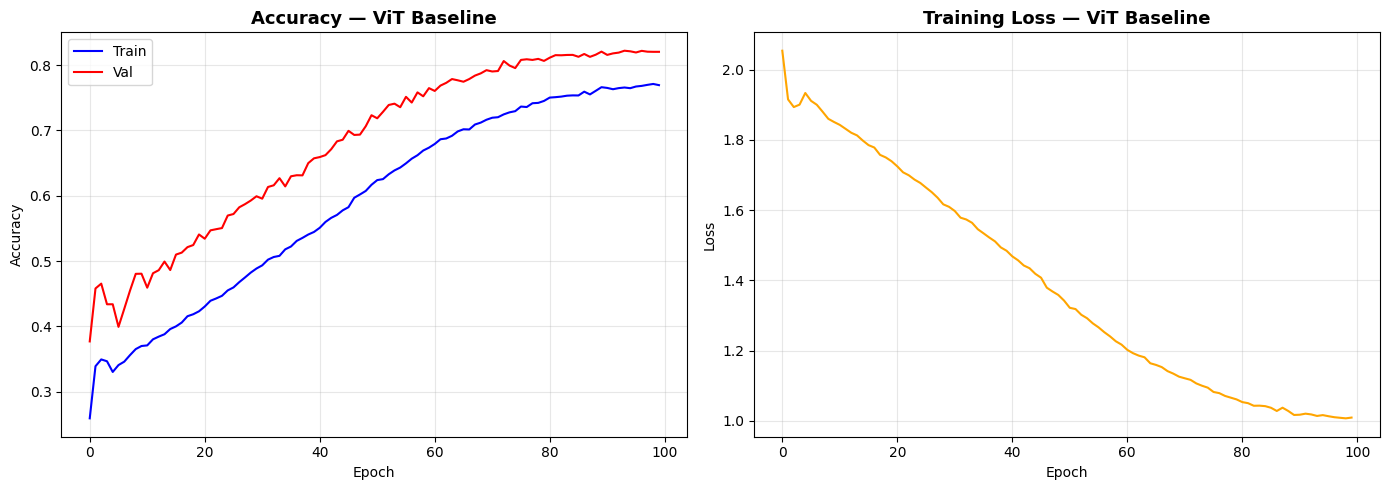

In [13]:
# ── TRAINING CURVES ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_accs, label='Train', color='blue')
ax1.plot(val_accs,   label='Val',   color='red')
ax1.set_title('Accuracy — ViT Baseline', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color='orange')
ax2.set_title('Training Loss — ViT Baseline', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('__3__training_curves.png', dpi=150)
plt.show()

In [14]:
# ── FULL EVALUATION ───────────────────────────────────────────
print("\n" + "="*55)
print("FULL EVALUATION")
print("="*55)

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        preds  = model(inputs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall    = recall_score(all_labels, all_preds, average='macro')
f1        = f1_score(all_labels, all_preds, average='macro')

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                             target_names=CIFAR10_CLASSES, digits=4))


FULL EVALUATION

  Accuracy          : 0.8221  (82.21%)
  Precision (macro) : 0.8207
  Recall    (macro) : 0.8221
  F1-score  (macro) : 0.8208

Per-class report:
              precision    recall  f1-score   support

    airplane     0.8084    0.8440    0.8258      1000
  automobile     0.8657    0.9280    0.8958      1000
        bird     0.8041    0.7430    0.7723      1000
         cat     0.7230    0.6630    0.6917      1000
        deer     0.8081    0.7620    0.7844      1000
         dog     0.7416    0.7460    0.7438      1000
        frog     0.8473    0.8770    0.8619      1000
       horse     0.8379    0.8790    0.8580      1000
        ship     0.8960    0.8870    0.8915      1000
       truck     0.8745    0.8920    0.8832      1000

    accuracy                         0.8221     10000
   macro avg     0.8207    0.8221    0.8208     10000
weighted avg     0.8207    0.8221    0.8208     10000



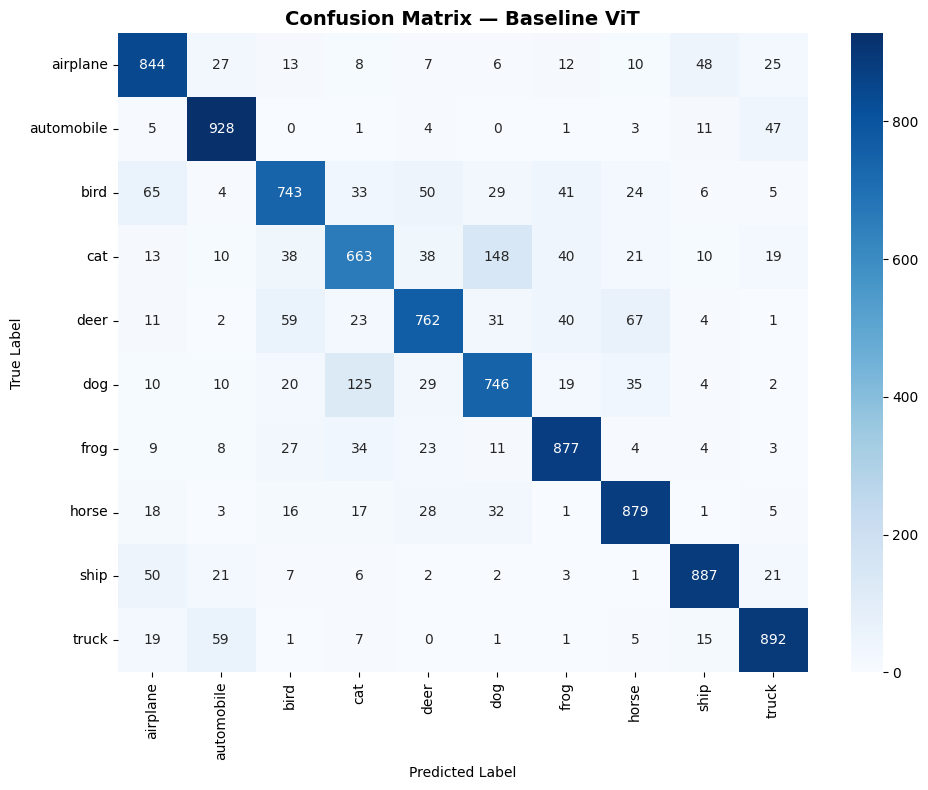

In [15]:
# ── CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title('Confusion Matrix — Baseline ViT', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('__3__confusion_matrix.png', dpi=150)
plt.show()

In [16]:
# ── MODEL COMPLEXITY METRICS ──────────────────────────────────
print("\n" + "="*55)
print("MODEL COMPLEXITY METRICS")
print("="*55)

size_mb = os.path.getsize(SAVE_PATH) / 1e6
dummy_gpu = torch.randn(1, 3, 32, 32).to(DEVICE)
dummy_batch = torch.randn(BATCH_SIZE, 3, 32, 32).to(DEVICE)
macs, _ = profile(model, inputs=(dummy_gpu,), verbose=False)
flops   = macs * 2

model.eval()

# ── GPU TIMING (CUDA events — most accurate method) ──────────
# Falls back gracefully to time.perf_counter() if no CUDA device
WARMUP_RUNS  = 50
MEASURE_RUNS = 500

if torch.cuda.is_available():
    # --- single image ---
    with torch.no_grad():
        for _ in range(WARMUP_RUNS):
            model(dummy_gpu)
    torch.cuda.synchronize()

    start_evt = torch.cuda.Event(enable_timing=True)
    end_evt   = torch.cuda.Event(enable_timing=True)
    gpu_single_times = []
    with torch.no_grad():
        for _ in range(MEASURE_RUNS):
            start_evt.record()
            model(dummy_gpu)
            end_evt.record()
            torch.cuda.synchronize()
            gpu_single_times.append(start_evt.elapsed_time(end_evt))   # ms
    gpu_single_ms = float(np.mean(gpu_single_times))

    # --- batch of 128 ---
    with torch.no_grad():
        for _ in range(WARMUP_RUNS):
            model(dummy_batch)
    torch.cuda.synchronize()

    gpu_batch_times = []
    with torch.no_grad():
        for _ in range(200):           # fewer runs; batch is heavier
            start_evt.record()
            model(dummy_batch)
            end_evt.record()
            torch.cuda.synchronize()
            gpu_batch_times.append(start_evt.elapsed_time(end_evt))
    gpu_batch_ms      = float(np.mean(gpu_batch_times))
    gpu_per_img_ms    = gpu_batch_ms / BATCH_SIZE
    gpu_throughput    = 1000.0 / gpu_per_img_ms          # imgs/sec
    timing_method_gpu = "CUDA events + torch.cuda.synchronize()"

else:
    # CPU fallback for the "GPU" block (machine has no GPU)
    with torch.no_grad():
        for _ in range(WARMUP_RUNS):
            model(dummy_gpu)
    import time as _time
    single_times = []
    with torch.no_grad():
        for _ in range(MEASURE_RUNS):
            t0 = _time.perf_counter()
            model(dummy_gpu)
            single_times.append((_time.perf_counter() - t0) * 1000)
    gpu_single_ms = float(np.mean(single_times))

    batch_times = []
    with torch.no_grad():
        for _ in range(200):
            t0 = _time.perf_counter()
            model(dummy_batch)
            batch_times.append((_time.perf_counter() - t0) * 1000)
    gpu_batch_ms      = float(np.mean(batch_times))
    gpu_per_img_ms    = gpu_batch_ms / BATCH_SIZE
    gpu_throughput    = 1000.0 / gpu_per_img_ms
    timing_method_gpu = "time.perf_counter() [no CUDA device]"

# ── CPU TIMING (time.perf_counter) ────────────────────────────
model_cpu     = model.cpu()
dummy_cpu_1   = torch.randn(1, 3, 32, 32)
dummy_cpu_b   = torch.randn(BATCH_SIZE, 3, 32, 32)

model_cpu.eval()
with torch.no_grad():
    for _ in range(10):               # warm-up
        model_cpu(dummy_cpu_1)

cpu_single_times = []
with torch.no_grad():
    for _ in range(MEASURE_RUNS):
        t0 = time.perf_counter()
        model_cpu(dummy_cpu_1)
        cpu_single_times.append((time.perf_counter() - t0) * 1000)
cpu_single_ms = float(np.mean(cpu_single_times))

cpu_batch_times = []
with torch.no_grad():
    for _ in range(50):               # fewer runs; CPU batch is slow
        t0 = time.perf_counter()
        model_cpu(dummy_cpu_b)
        cpu_batch_times.append((time.perf_counter() - t0) * 1000)
cpu_batch_ms   = float(np.mean(cpu_batch_times))
cpu_per_img_ms = cpu_batch_ms / BATCH_SIZE
cpu_throughput = 1000.0 / cpu_per_img_ms

# Move model back to original device for any further use
model = model_cpu.to(DEVICE)

# ── PRINT SUMMARY ─────────────────────────────────────────────
print(f"  Parameters        : {total_params:,}")
print(f"  Model size        : {size_mb:.2f} MB")
print(f"  FLOPs             : {flops/1e9:.3f} GFLOPs")
print(f"\n  [GPU] single img  : {gpu_single_ms:.3f} ms")
print(f"  [GPU] batch-128   : {gpu_batch_ms:.3f} ms  ({gpu_per_img_ms:.3f} ms/img)")
print(f"  [GPU] throughput  : {gpu_throughput:.1f} imgs/sec")
print(f"\n  [CPU] single img  : {cpu_single_ms:.3f} ms")
print(f"  [CPU] batch-128   : {cpu_batch_ms:.3f} ms  ({cpu_per_img_ms:.3f} ms/img)")
print(f"  [CPU] throughput  : {cpu_throughput:.1f} imgs/sec")


MODEL COMPLEXITY METRICS
  Parameters        : 12,470,026
  Model size        : 49.92 MB
  FLOPs             : 1.616 GFLOPs

  [GPU] single img  : 8.823 ms
  [GPU] batch-128   : 33.459 ms  (0.261 ms/img)
  [GPU] throughput  : 3825.6 imgs/sec

  [CPU] single img  : 19.058 ms
  [CPU] batch-128   : 780.162 ms  (6.095 ms/img)
  [CPU] throughput  : 164.1 imgs/sec


In [17]:
# ── SAVE METRICS JSON ─────────────────────────────────────────
baseline_metrics = {
    "accuracy"  : acc,
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "params"    : total_params,
    "size_mb"   : size_mb,
    "flops_G"   : flops / 1e9,
    "inference_ms": {
        "single_img_gpu_ms"  : round(gpu_single_ms, 4),
        "batch128_gpu_ms"    : round(gpu_batch_ms, 4),
        "per_img_gpu_ms"     : round(gpu_per_img_ms, 4),
        "throughput_imgs_sec": round(gpu_throughput, 2),
        "timing_method"      : timing_method_gpu,
    },
    "inference_ms_cpu": {
        "single_img_cpu_ms"  : round(cpu_single_ms, 4),
        "batch128_cpu_ms"    : round(cpu_batch_ms, 4),
        "per_img_cpu_ms"     : round(cpu_per_img_ms, 4),
        "throughput_imgs_sec": round(cpu_throughput, 2),
        "timing_method"      : "time.perf_counter()",
    },
}
with open("__3__baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("\n✓ Metrics saved to __3__baseline_metrics.json")


✓ Metrics saved to __3__baseline_metrics.json



Sample 1 — True label: cat


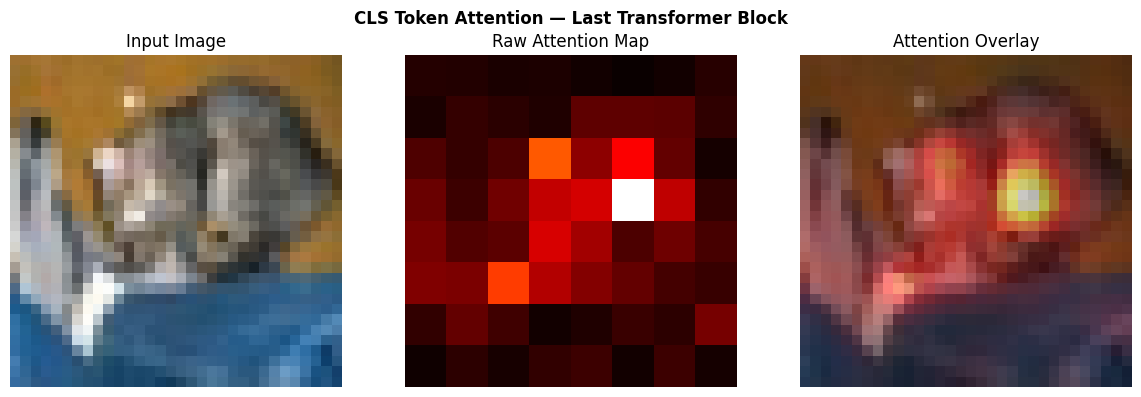

✓ Attention map saved to __3__attention_sample_1.png

Sample 2 — True label: ship


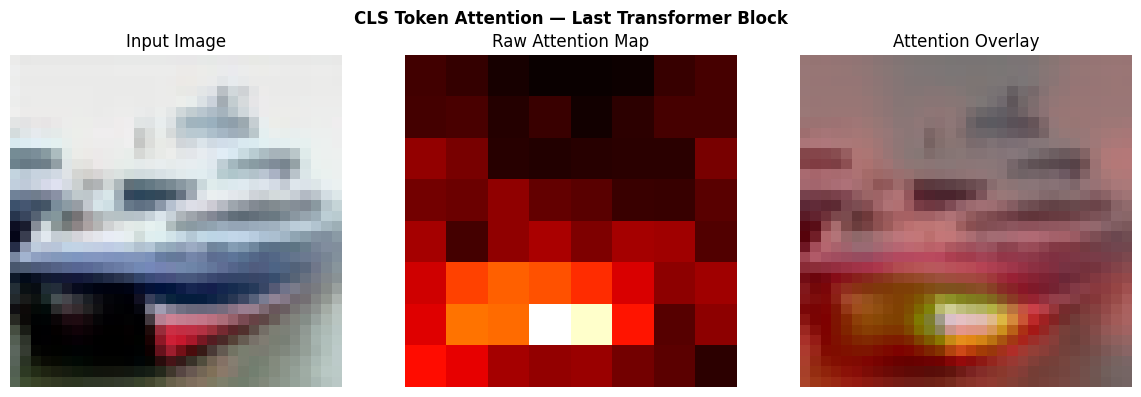

✓ Attention map saved to __3__attention_sample_2.png

Sample 3 — True label: ship


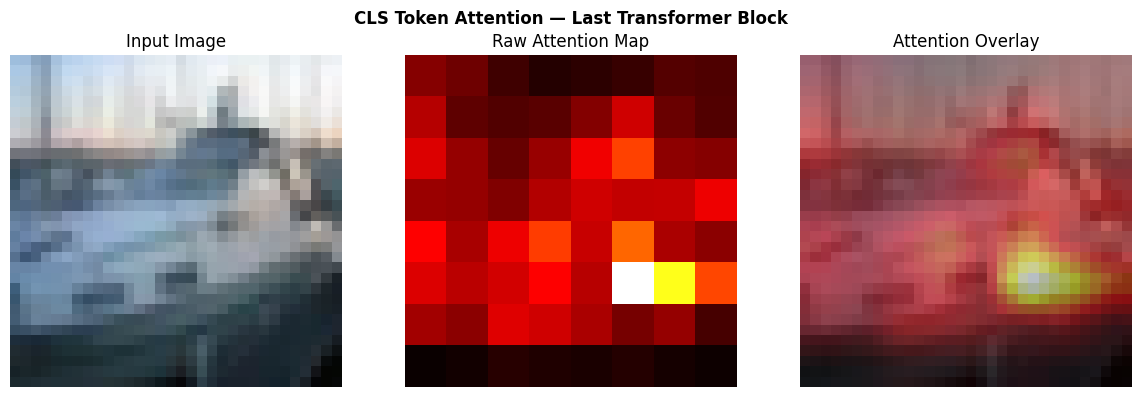

✓ Attention map saved to __3__attention_sample_3.png


In [20]:
# ── ATTENTION MAP VISUALISATION (ViT-specific) ───────────────
# Inspect what the CLS token attends to in the last block.
# This is unique to ViT and useful for your PFE report.

def visualise_attention(model, image_tensor, save_path="__3__attention_map.png"):
    """
    Extracts the attention weights of the last Transformer block
    and overlays the CLS-to-patch attention on the input image.
    """
    model.eval()
    attention_maps = {}

    # Hook to capture attention weights from the last block
    def hook_fn(module, input, output):
        # We need raw attention before the dropout — re-compute from QKV
        pass

    # Simpler approach: forward pass, extract attn from last block manually
    x = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        B = x.shape[0]
        x_emb = model.patch_embed(x)
        cls   = model.cls_token.expand(B, -1, -1)
        x_emb = torch.cat([cls, x_emb], dim=1)
        x_emb = model.pos_drop(x_emb + model.pos_embed)

        # Forward through all blocks except the last
        for blk in list(model.blocks)[:-1]:
            x_emb = blk(x_emb)

        # Last block: get raw attention weights
        last_blk = list(model.blocks)[-1]
        x_norm   = last_blk.norm1(x_emb)
        B2, N, C = x_norm.shape
        qkv = (last_blk.attn.qkv(x_norm)
                   .reshape(B2, N, 3, last_blk.attn.num_heads, last_blk.attn.head_dim)
                   .permute(2, 0, 3, 1, 4))
        q, k, _ = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * last_blk.attn.scale
        attn = attn.softmax(dim=-1)               # (1, heads, N, N)

    # CLS token (index 0) attention to all patches (indices 1..)
    # Average across heads
    cls_attn = attn[0, :, 0, 1:].mean(dim=0)     # (num_patches,)
    n        = int(cls_attn.shape[0] ** 0.5)
    attn_map = cls_attn.reshape(n, n).cpu().numpy()

    # Upsample to 32×32
    from PIL import Image as PILImage
    attn_img = PILImage.fromarray(
        (attn_map / attn_map.max() * 255).astype(np.uint8)
    ).resize((32, 32), PILImage.BILINEAR)

    # Original image (denormalise)
    img_np = image_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)).clip(0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_np);              axes[0].set_title('Input Image');        axes[0].axis('off')
    axes[1].imshow(attn_map, cmap='hot'); axes[1].set_title('Raw Attention Map'); axes[1].axis('off')
    axes[2].imshow(img_np)
    axes[2].imshow(np.array(attn_img), cmap='hot', alpha=0.5)
    axes[2].set_title('Attention Overlay'); axes[2].axis('off')

    plt.suptitle('CLS Token Attention — Last Transformer Block', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✓ Attention map saved to {save_path}")


# Visualise attention on a few test samples
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE), strict=False)
test_imgs, test_labels = next(iter(test_loader))
for i in range(3):
    print(f"\nSample {i+1} — True label: {CIFAR10_CLASSES[test_labels[i]]}")
    visualise_attention(model, test_imgs[i],
                        save_path=f"__3__attention_sample_{i+1}.png")

In [21]:
# ── SAVE FULL CHECKPOINT ──────────────────────────────────────
config_dict = {
    "model_name" : "vit_cifar10",
    "architecture": {
        "img_size"   : IMG_SIZE,
        "patch_size" : PATCH_SIZE,
        "num_patches": NUM_PATCHES,
        "embed_dim"  : EMBED_DIM,
        "depth"      : DEPTH,
        "num_heads"  : NUM_HEADS,
        "mlp_ratio"  : MLP_RATIO,
        "dropout"    : DROP_RATE,
    },
    "num_classes" : NUM_CLASSES,
    "input_size"  : [3, IMG_SIZE, IMG_SIZE],
    "normalization": {
        "mean": CIFAR_MEAN,
        "std" : CIFAR_STD,
    },
    "training": {
        "batch_size"    : BATCH_SIZE,
        "epochs"        : EPOCHS,
        "learning_rate" : LR,
        "optimizer"     : "AdamW",
        "weight_decay"  : 0.05,
        "scheduler"     : "WarmupCosine",
        "warmup_epochs" : WARMUP_EPOCHS,
        "grad_clip"     : 1.0,
        "label_smoothing": 0.1,
    }
}

torch.save({
    "model_state_dict": model.state_dict(),
    "config"          : config_dict,
    "classes"         : CIFAR10_CLASSES,
}, "__3__model_checkpoint.pth")

print("\n" + "="*55)
print("BASELINE COMPLETE — ready for compression experiments")
print("="*55)
print(f"  Weights    → {SAVE_PATH}")
print(f"  Checkpoint → __3__model_checkpoint.pth")
print(f"  Metrics    → __3__baseline_metrics.json")
print(f"  Plots      → __3__training_curves.png")
print(f"               __3__confusion_matrix.png")
print(f"               __3__attention_sample_1/2/3.png")

# %%
# ── LOADING THE MODEL (reference) ────────────────────────────
# checkpoint = torch.load("__3__model_checkpoint.pth", map_location="cpu")
# config     = checkpoint["config"]
# classes    = checkpoint["classes"]
# arch       = config["architecture"]
#
# model = ViTCIFAR(
#     img_size    = arch["img_size"],
#     patch_size  = arch["patch_size"],
#     num_classes = config["num_classes"],
#     embed_dim   = arch["embed_dim"],
#     depth       = arch["depth"],
#     num_heads   = arch["num_heads"],
#     mlp_ratio   = arch["mlp_ratio"],
#     dropout     = arch["dropout"],
# )
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()


BASELINE COMPLETE — ready for compression experiments
  Weights    → __3__baseline_vit_cifar10.pth
  Checkpoint → __3__model_checkpoint.pth
  Metrics    → __3__baseline_metrics.json
  Plots      → __3__training_curves.png
               __3__confusion_matrix.png
               __3__attention_sample_1/2/3.png
